In [2]:
import pandas as pd
import numpy as np
from numpy.ma.core import remainder
from sklearn.metrics._plot import confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import VotingClassifier
from sklearn.preprocessing import StandardScaler,OneHotEncoder,LabelEncoder
from sklearn.metrics import classification_report, f1_score, accuracy_score, log_loss, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.compose import make_column_selector,make_column_transformer


In [3]:
df=pd.read_csv("../Datasets/Sonar.csv")
df.columns

Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21',
       'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31',
       'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41',
       'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51',
       'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'Class'],
      dtype='str')

In [10]:
le=LabelEncoder()
X=df.drop(columns=['Class'])
Y=le.fit_transform(df["Class"])
print(le.classes_)

['M' 'R']


In [7]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.3,random_state=25,stratify=Y)

In [9]:
ddc=DecisionTreeClassifier(random_state=25)
knn=KNeighborsClassifier()
nb=GaussianNB()
voting=VotingClassifier(estimators=[("ddc",ddc),("knn",knn),("nb",nb)])
# building esemble
voting.fit(X_train,Y_train)
y_pred=voting.predict(X_test)
print(classification_report(Y_test,y_pred,target_names=le.classes_))

              precision    recall  f1-score   support

           M       0.67      0.85      0.75        34
           R       0.75      0.52      0.61        29

    accuracy                           0.70        63
   macro avg       0.71      0.69      0.68        63
weighted avg       0.71      0.70      0.69        63



In [11]:
# hard voting
ddc_1=DecisionTreeClassifier(random_state=25)
ddc_2=DecisionTreeClassifier(random_state=25,max_depth=3)
knn_1=KNeighborsClassifier(n_neighbors=5)
knn_2=KNeighborsClassifier(n_neighbors=3)

nb=GaussianNB()
voting=VotingClassifier(estimators=[("tree_1",ddc_1),("tree_2",ddc_2),("knn_1",knn_1),("knn_2",knn_2),("nb",nb)])
voting.fit(X_train,Y_train)
y_pred=voting.predict(X_test)
print(classification_report(Y_test,y_pred,target_names=le.classes_))


              precision    recall  f1-score   support

           M       0.67      0.85      0.75        34
           R       0.75      0.52      0.61        29

    accuracy                           0.70        63
   macro avg       0.71      0.69      0.68        63
weighted avg       0.71      0.70      0.69        63



In [12]:
for i in range(len(voting.estimators_)):
    print(f"estimator{i} : {voting.estimators_[i]} ")
    print(f"Accuracy Score : {accuracy_score(Y_test,voting.estimators_[i].predict(X_test))}")

estimator0 : DecisionTreeClassifier(random_state=25) 
Accuracy Score : 0.6984126984126984
estimator1 : DecisionTreeClassifier(max_depth=3, random_state=25) 
Accuracy Score : 0.6666666666666666
estimator2 : KNeighborsClassifier() 
Accuracy Score : 0.746031746031746
estimator3 : KNeighborsClassifier(n_neighbors=3) 
Accuracy Score : 0.8095238095238095
estimator4 : GaussianNB() 
Accuracy Score : 0.6349206349206349


In [17]:
# Soft voting
from sklearn.metrics import log_loss



voting=VotingClassifier(estimators=[("tree_1",ddc_1),("tree_2",ddc_2),("knn_1",knn_1),("knn_2",knn_2),("nb",nb)],voting="soft")

voting.fit(X_train, Y_train)
y_pred=voting.predict(X_test)
# Predicted probabilities
y_prob = voting.predict_proba(X_test)

# Calculate Log Loss
loss = log_loss(Y_test, y_prob)

print(classification_report(Y_test,y_pred,target_names=le.classes_))
print("Log Loss:", loss)



              precision    recall  f1-score   support

           M       0.68      0.88      0.77        34
           R       0.79      0.52      0.62        29

    accuracy                           0.71        63
   macro avg       0.74      0.70      0.70        63
weighted avg       0.73      0.71      0.70        63

Log Loss: 0.4923458955919867


In [19]:
voting=VotingClassifier(estimators=[("tree_1",ddc_1),("tree_2",ddc_2),("knn_1",knn_1),("knn_2",knn_2),("nb",nb)],voting="soft",weights=[7,6,7.5,8.1,6.3])
voting.fit(X_train, Y_train)
y_pred=voting.predict(X_test)
y_prob = voting.predict_proba(X_test)
loss = log_loss(Y_test, y_prob)
print(classification_report(Y_test,y_pred,target_names=le.classes_))
print("Log Loss:", loss)


              precision    recall  f1-score   support

           M       0.68      0.88      0.77        34
           R       0.79      0.52      0.62        29

    accuracy                           0.71        63
   macro avg       0.74      0.70      0.70        63
weighted avg       0.73      0.71      0.70        63

Log Loss: 0.4792459136222534


In [20]:
df_hr=pd.read_csv("../Datasets/HR_comma_sep.csv")

In [21]:
df_hr.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='str')

In [23]:
X=df_hr.drop(columns=['left'])
Y=df_hr["left"]
Y=df_hr["left"]
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.3,random_state=25,stratify=Y)

In [25]:
ohe=OneHotEncoder(drop="first",sparse_output=False).set_output(transform="pandas")
trms=make_column_transformer((ohe,make_column_selector(dtype_include="object")),remainder="passthrough",verbose_feature_names_out=False)
x_train_ohe=trms.fit_transform(X_train)
x_test_ohe=trms.transform(X_test)

In [28]:
ddc=DecisionTreeClassifier(random_state=25)
knn=KNeighborsClassifier()
nb=GaussianNB()
voting=VotingClassifier(estimators=[("ddc",ddc),("knn",knn),("nb",nb)])
# building esemble
voting.fit(x_train_ohe,Y_train)
y_pred=voting.predict(x_test_ohe)
print(classification_report(Y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      0.96      0.97      3429
           1       0.87      0.96      0.91      1070

    accuracy                           0.96      4499
   macro avg       0.93      0.96      0.94      4499
weighted avg       0.96      0.96      0.96      4499



In [31]:
ddc_1=DecisionTreeClassifier(random_state=25)
ddc_2=DecisionTreeClassifier(random_state=25,max_depth=3)
knn_1=KNeighborsClassifier(n_neighbors=5)
knn_2=KNeighborsClassifier(n_neighbors=3)
nb=GaussianNB()
voting=VotingClassifier([("tree_1",ddc_1),("tree_2",ddc_2),("knn_1",knn_1),("knn_2",knn_2),("nb",nb)])
voting.fit(x_train_ohe,Y_train)
y_pred=voting.predict(x_test_ohe)
print(classification_report(Y_test,y_pred,target_names=le.classes_))

              precision    recall  f1-score   support

           M       0.99      0.97      0.98      3429
           R       0.90      0.95      0.92      1070

    accuracy                           0.96      4499
   macro avg       0.94      0.96      0.95      4499
weighted avg       0.96      0.96      0.96      4499



In [32]:
for i in range(len(voting.estimators_)):
    print(f"estimator{i} : {voting.estimators_[i]} ")
    print(f"Accuracy Score : {accuracy_score(Y_test,voting.estimators_[i].predict(x_test_ohe))}")

estimator0 : DecisionTreeClassifier(random_state=25) 
Accuracy Score : 0.9813291842631696
estimator1 : DecisionTreeClassifier(max_depth=3, random_state=25) 
Accuracy Score : 0.9559902200488998
estimator2 : KNeighborsClassifier() 
Accuracy Score : 0.9373194043120694
estimator3 : KNeighborsClassifier(n_neighbors=3) 
Accuracy Score : 0.937541675927984
estimator4 : GaussianNB() 
Accuracy Score : 0.7141587019337631


In [30]:
for i in range(len(voting.estimators_)):
    print(f"estimator{i}: {voting.estimators_[i]} ")
    print(f"Accuracy Score: {accuracy_score(Y_test,voting.estimators_[i].predict(x_test_ohe))}")

estimator0: DecisionTreeClassifier(random_state=25) 
Accuracy Score: 0.9813291842631696
estimator1: KNeighborsClassifier() 
Accuracy Score: 0.9373194043120694
estimator2: GaussianNB() 
Accuracy Score: 0.7141587019337631


In [33]:
voting=VotingClassifier([("tree_1",ddc_1),("tree_2",ddc_2),("knn_1",knn_1),("knn_2",knn_2),("nb",nb)],voting="soft")
voting.fit(x_train_ohe,Y_train)
y_pred=voting.predict(x_test_ohe)
y_pred_porb=voting.predict_proba(x_test_ohe)
print(classification_report(Y_test,y_pred,target_names=le.classes_))
print(f"log loss:{log_loss(Y_test,y_pred_porb)}")


              precision    recall  f1-score   support

           M       0.99      0.98      0.98      3429
           R       0.93      0.95      0.94      1070

    accuracy                           0.97      4499
   macro avg       0.96      0.97      0.96      4499
weighted avg       0.97      0.97      0.97      4499

log loss:0.1403693382202133


In [36]:
from sklearn.metrics import confusion_matrix
voting=VotingClassifier([("tree_1",ddc_1),("tree_2",ddc_2),("knn_1",knn_1),("knn_2",knn_2),("nb",nb)],voting="soft",weights=[4,2.5,1,1,0])
voting.fit(x_train_ohe,Y_train)
y_pred=voting.predict(x_test_ohe)
y_prob = voting.predict_proba(x_test_ohe)
loss = log_loss(Y_test, y_prob)
print(classification_report(Y_test,y_pred,target_names=le.classes_))
print("Log Loss:", loss)
print(confusion_matrix(Y_test,y_pred))


              precision    recall  f1-score   support

           M       0.99      0.99      0.99      3429
           R       0.98      0.97      0.97      1070

    accuracy                           0.99      4499
   macro avg       0.98      0.98      0.98      4499
weighted avg       0.99      0.99      0.99      4499

Log Loss: 0.07071178612705878
[[3403   26]
 [  30 1040]]


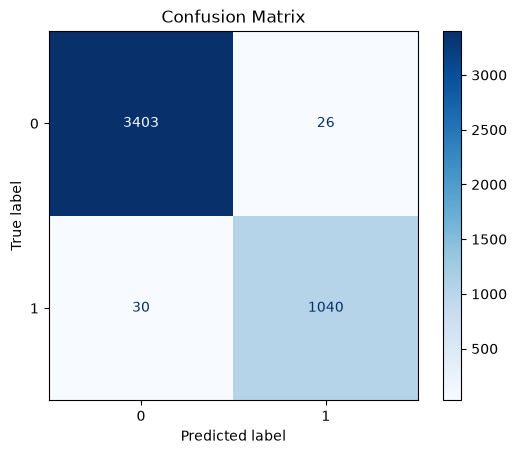

In [37]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(Y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

In [38]:
print(accuracy_score(Y_test,y_pred))

0.9875527895087798
